In [4]:
!pip install scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [10]:
# Load the Online Retail dataset

df = pd.read_excel("Online Retail.xlsx")

# Display the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
# Check the shape of the dataset

print("Number of rows and columns:", df.shape)

Number of rows and columns: (541909, 8)


In [12]:
# Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [13]:
# Check missing values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5268


In [15]:
# Remove rows with missing CustomerID

df = df.dropna(subset=['CustomerID'])

print("Dataset shape after removing missing CustomerID:", df.shape)

Dataset shape after removing missing CustomerID: (406829, 8)


In [16]:
# Remove cancelled transactions

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Dataset shape after removing cancelled invoices:", df.shape)

Dataset shape after removing cancelled invoices: (397924, 8)


In [17]:
# Remove invalid quantities and prices

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Dataset shape after cleaning:", df.shape)


Dataset shape after cleaning: (397884, 8)


In [18]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (392692, 8)


In [19]:
# Check cleaned dataset

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [20]:
# Calculate total purchase value for each transaction

df['TotalPurchaseValue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPurchaseValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [21]:
# Descriptive statistics

df[['Quantity', 'UnitPrice', 'TotalPurchaseValue']].describe()

,Quantity,UnitPrice,TotalPurchaseValue
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [22]:
# Calculate total sales

total_sales = df['TotalPurchaseValue'].sum()

print("Total Sales:", total_sales)

Total Sales: 8887208.894000001


In [23]:
# Check InvoiceDate data type

print(df['InvoiceDate'].dtype)

datetime64[us]


In [24]:
# Set the analysis date

analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [25]:
# Create RFM features for each customer

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPurchaseValue': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [26]:
# Descriptive statistics of RFM features

rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [27]:
# Check RFM dataset information

print("Number of customers:", len(rfm))
print("\nRFM Dataset:")
rfm.head(10)

Number of customers: 4338

RFM Dataset:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


In [28]:
# Select RFM features for clustering

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [29]:
# Standardize the RFM features

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print("RFM features standardized successfully!")


RFM features standardized successfully!


In [30]:
# Create a DataFrame of standardized RFM values

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [31]:
# Elbow Method to find the optimal number of clusters

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
print(inertia)

Inertia values:
[9014.566279572977, 5441.3235868296615, 4096.300210662247, 3119.789859800152, 2473.7933635647614, 2023.586627223549, 1717.0110430839188, 1468.7871021842977, 1281.0480511013266]


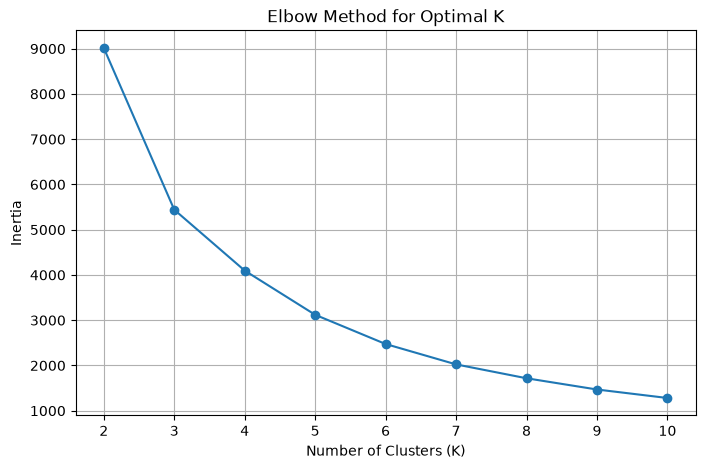

In [32]:
# Plot the Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [33]:
# Apply K-Means clustering

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

print("K-Means clustering completed successfully!")

K-Means clustering completed successfully!


In [34]:
# Display customers with their cluster labels

rfm.head(10)

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1
12352.0,36,8,2506.04,0
12353.0,204,1,89.00,1
12354.0,232,1,1079.40,1
12355.0,214,1,459.40,1


In [35]:
# Count customers in each cluster

cluster_counts = rfm['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


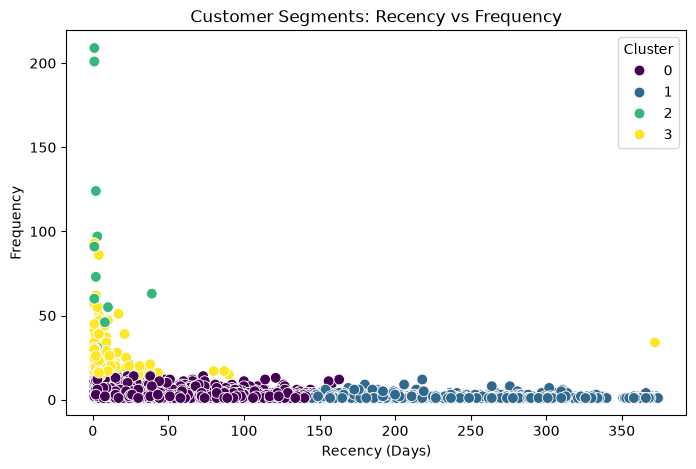

In [36]:
# Scatter plot: Recency vs Frequency

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency')
plt.legend(title='Cluster')

plt.show()

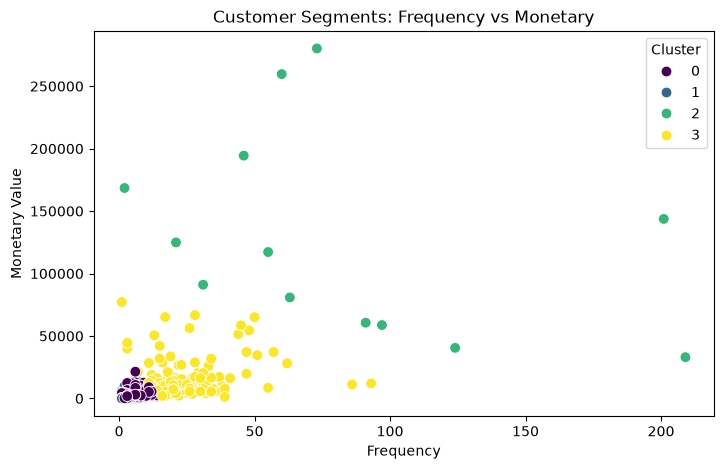

In [37]:
# Scatter plot: Frequency vs Monetary

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')

plt.show()

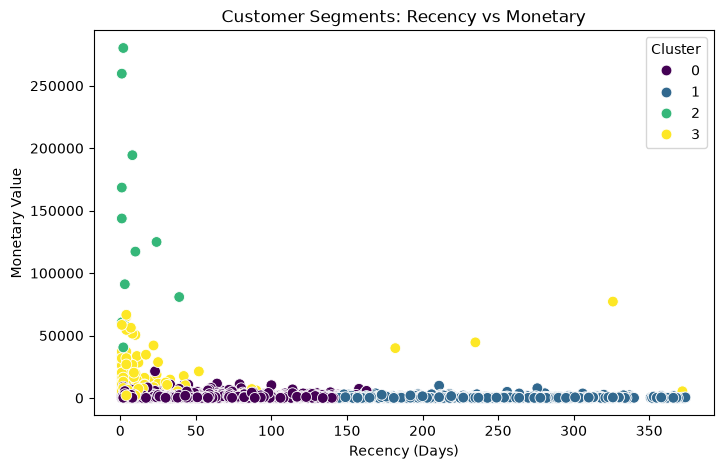

In [38]:
# Scatter plot: Recency vs Monetary

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')

plt.show()

In [39]:
# Calculate average RFM values for each cluster

cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


In [40]:
# Round cluster profile values for better readability

cluster_profile = cluster_profile.round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


In [41]:
# Display cluster profiles

print("Customer Segment Profiles:")
print(cluster_profile)

Customer Segment Profiles:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1353.63
1         248.08       1.55     478.85
2           7.38      82.54  127187.96
3          15.50      22.33   12690.50


In [42]:
# Create customer segment descriptions

for cluster in cluster_profile.index:
    recency = cluster_profile.loc[cluster, 'Recency']
    frequency = cluster_profile.loc[cluster, 'Frequency']
    monetary = cluster_profile.loc[cluster, 'Monetary']
    
    print(f"\nCluster {cluster}")
    print(f"Average Recency: {recency:.2f}")
    print(f"Average Frequency: {frequency:.2f}")
    print(f"Average Monetary: {monetary:.2f}")


Cluster 0
Average Recency: 43.70
Average Frequency: 3.68
Average Monetary: 1353.63

Cluster 1
Average Recency: 248.08
Average Frequency: 1.55
Average Monetary: 478.85

Cluster 2
Average Recency: 7.38
Average Frequency: 82.54
Average Monetary: 127187.96

Cluster 3
Average Recency: 15.50
Average Frequency: 22.33
Average Monetary: 12690.50


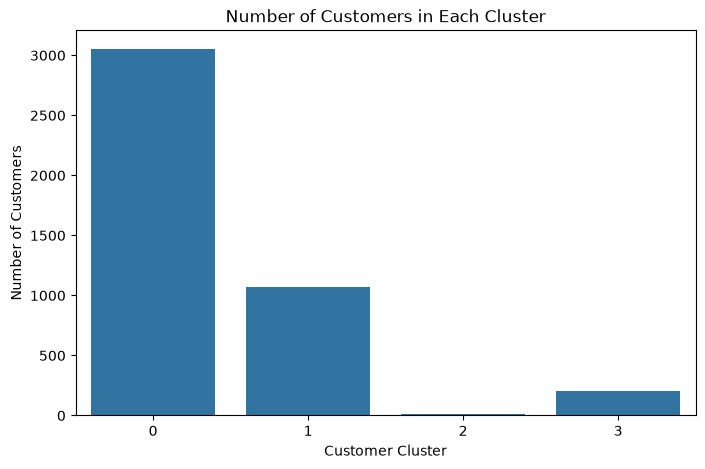

In [43]:
# Bar chart showing number of customers in each cluster

plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')

plt.show()

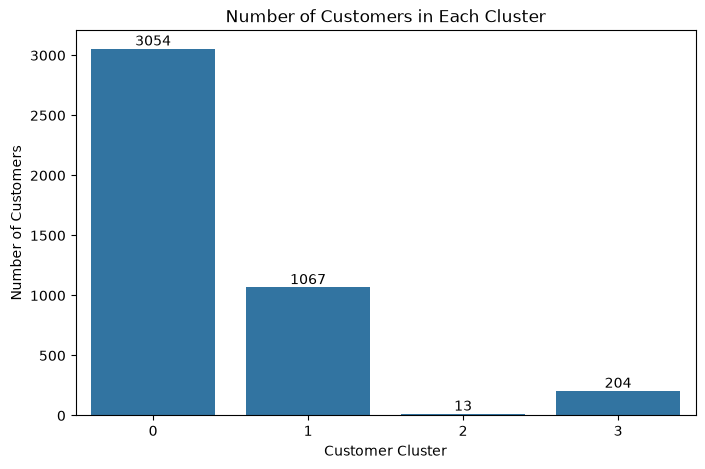

In [44]:
# Bar chart with customer count labels

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [45]:
# Create a complete cluster profile

cluster_summary = rfm.groupby('Cluster').agg(
    Customers=('Cluster', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.70,3.68,1353.63
1,1067,248.08,1.55,478.85
2,13,7.38,82.54,127187.96
3,204,15.50,22.33,12690.50


In [46]:
# Identify the highest and lowest performing clusters

best_frequency_cluster = cluster_summary['Avg_Frequency'].idxmax()
best_monetary_cluster = cluster_summary['Avg_Monetary'].idxmax()
recent_cluster = cluster_summary['Avg_Recency'].idxmin()
inactive_cluster = cluster_summary['Avg_Recency'].idxmax()

print("Highest Frequency Cluster:", best_frequency_cluster)
print("Highest Monetary Cluster:", best_monetary_cluster)
print("Most Recent Customers Cluster:", recent_cluster)
print("Least Recent / At-Risk Cluster:", inactive_cluster)

Highest Frequency Cluster: 2
Highest Monetary Cluster: 2
Most Recent Customers Cluster: 2
Least Recent / At-Risk Cluster: 1


In [47]:
# Marketing recommendations for each customer segment

print("""
MARKETING RECOMMENDATIONS

1. High-Value Customers:
   Provide loyalty rewards, exclusive offers, premium products,
   and personalized recommendations to retain these customers.

2. Loyal Customers:
   Encourage repeat purchases through loyalty programs,
   membership benefits, and cross-selling offers.

3. Potential Customers:
   Use personalized discounts, product recommendations,
   and limited-time offers to increase purchase frequency.

4. At-Risk Customers:
   Send re-engagement emails, special discounts, and win-back
   campaigns to encourage them to return.
""")


MARKETING RECOMMENDATIONS

1. High-Value Customers:
   Provide loyalty rewards, exclusive offers, premium products,
   and personalized recommendations to retain these customers.

2. Loyal Customers:
   Encourage repeat purchases through loyalty programs,
   membership benefits, and cross-selling offers.

3. Potential Customers:
   Use personalized discounts, product recommendations,
   and limited-time offers to increase purchase frequency.

4. At-Risk Customers:
   Send re-engagement emails, special discounts, and win-back
   campaigns to encourage them to return.



In [48]:
# Final business insights

print("""
FINAL INSIGHTS

• K-Means clustering successfully divided customers into distinct
  groups based on Recency, Frequency, and Monetary behaviour.

• RFM analysis helps identify customers based on how recently,
  how frequently, and how much they purchase.

• High-value customers should receive loyalty benefits and
  personalized offers to improve retention.

• At-risk customers should be targeted with re-engagement
  campaigns and special discounts.

• Potential customers can be encouraged to purchase more
  frequently through personalized recommendations and promotions.

• Customer segmentation allows the company to use different
  marketing strategies for different customer groups instead
  of using the same strategy for every customer.
""")



FINAL INSIGHTS

• K-Means clustering successfully divided customers into distinct
  groups based on Recency, Frequency, and Monetary behaviour.

• RFM analysis helps identify customers based on how recently,
  how frequently, and how much they purchase.

• High-value customers should receive loyalty benefits and
  personalized offers to improve retention.

• At-risk customers should be targeted with re-engagement
  campaigns and special discounts.

• Potential customers can be encouraged to purchase more
  frequently through personalized recommendations and promotions.

• Customer segmentation allows the company to use different
  marketing strategies for different customer groups instead
  of using the same strategy for every customer.



# OASIS INFOBYTE INTERNSHIP

## TASK 2: CUSTOMER SEGMENTATION ANALYSIS

### Objective
Apply K-Means clustering to segment an e-commerce company's customer base based on purchasing behaviour using RFM analysis.

### Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook